In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import boto3







df = pd.read_csv('ufc_fights_ml.csv')
df




,fight_id,event_date,weight_class,outcome,fighter_a_name,fighter_b_name,fighter_a_age,fighter_a_height,fighter_a_reach,fighter_a_weight,...,fighter_b_takedown_defense,fighter_b_submission_attempts_per_fight,fighter_b_ko_tko_win_rate,fighter_b_control_time_per_fight,sig_strikes_landed_diff,sig_strike_accuracy_diff,takedowns_landed_diff,takedown_defense_diff,reach_diff,age_diff
0,00c6a2ef07ca51da,"December 14, 2024",Welterweight,0,Colby Covington,Joaquin Buckley,37.2,71.0,72.0,170.0,...,73,0.1,52.380952,5.306122,-0.41,1,1.86,-5,-4.0,6.2
1,7.52E+15,"December 14, 2024",Featherweight,1,Cub Swanson,Billy Quarantillo,41.5,68.0,70.0,145.0,...,61,1.0,33.333333,10.948276,-2.65,-3,-0.46,2,0.0,5.1
2,1a635a5e4551e7d5,"December 14, 2024",Flyweight,1,Manel Kape,Bruno Silva,31.5,65.0,68.0,125.0,...,60,0.2,28.571429,0.000000,1.50,6,-1.50,21,3.0,-3.7
3,7b1bc4ff776f12c1,"December 14, 2024",Light Heavyweight,0,Vitor Petrino,Dustin Jacoby,27.7,74.0,77.0,205.0,...,62,0.0,30.000000,1.456311,-2.50,-2,2.91,9,1.0,-9.4
4,5238f6470d0557fb,"December 14, 2024",Bantamweight,0,Adrian Yanez,Daniel Marcos,31.4,67.0,70.0,135.0,...,84,0.0,5.882353,13.533333,1.12,-12,-0.99,-3,1.0,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8052,d5e3be7a07c48b08,"July 12, 2025",Welterweight,1,Jake Matthews,Chidi Njokuani,30.9,71.0,73.0,170.0,...,73,0.2,24.000000,0.000000,-1.28,-19,1.51,-6,-7.0,-5.7
8053,46bc1338a50cbeac,"July 12, 2025",Women's Flyweight,0,Lauren Murphy,Eduarda Moura,42.0,65.0,67.0,125.0,...,80,0.3,8.333333,12.133333,0.90,1,-2.64,-13,0.0,10.6
8054,5c650ae2193ab1bc,"July 12, 2025",Heavyweight,0,Kennedy Nzechukwu,Valter Walker,33.1,77.0,83.0,236.0,...,0,2.0,0.000000,31.111111,3.43,-3,-4.88,80,5.0,5.5
8055,7f33fbdc35afd721,"July 12, 2025",Lightweight,0,Mitch Ramirez,Mike Davis,32.7,71.0,71.0,155.0,...,60,0.8,16.666667,28.686131,-1.22,-9,-1.81,-35,-1.0,-0.1


In [11]:
NUMERICAL_FIGHTER_STATS = [
    'age', 'height', 'reach', 'weight', 'total_fights', 'win_percentage',
    'recent_wins', 'win_streak', 'sig_strikes_landed_per_min',
    'sig_strikes_absorbed_per_min', 'sig_strike_accuracy', 'sig_strike_defense',
    'takedowns_landed_per_fight', 'takedown_attempts_per_fight',
    'takedown_defense', 'submission_attempts_per_fight',
    'ko_tko_win_rate', 'control_time_per_fight'
]

In [12]:
df['event_date'] = pd.to_datetime(df['event_date'])

In [13]:


all_numerical_raw_cols = [f"fighter_a_{s}" for s in NUMERICAL_FIGHTER_STATS] + [f"fighter_b_{s}" for s in NUMERICAL_FIGHTER_STATS]


for stat in NUMERICAL_FIGHTER_STATS:
    all_numerical_raw_cols.append(f'fighter_a_{stat}')
    all_numerical_raw_cols.append(f'fighter_b_{stat}')

len(all_numerical_raw_cols)
df[all_numerical_raw_cols].columns



Index(['fighter_a_age', 'fighter_a_height', 'fighter_a_reach',
       'fighter_a_weight', 'fighter_a_total_fights',
       'fighter_a_win_percentage', 'fighter_a_recent_wins',
       'fighter_a_win_streak', 'fighter_a_sig_strikes_landed_per_min',
       'fighter_a_sig_strikes_absorbed_per_min',
       'fighter_a_sig_strike_accuracy', 'fighter_a_sig_strike_defense',
       'fighter_a_takedowns_landed_per_fight',
       'fighter_a_takedown_attempts_per_fight', 'fighter_a_takedown_defense',
       'fighter_a_submission_attempts_per_fight', 'fighter_a_ko_tko_win_rate',
       'fighter_a_control_time_per_fight', 'fighter_b_age', 'fighter_b_height',
       'fighter_b_reach', 'fighter_b_weight', 'fighter_b_total_fights',
       'fighter_b_win_percentage', 'fighter_b_recent_wins',
       'fighter_b_win_streak', 'fighter_b_sig_strikes_landed_per_min',
       'fighter_b_sig_strikes_absorbed_per_min',
       'fighter_b_sig_strike_accuracy', 'fighter_b_sig_strike_defense',
       'fighter_b_takedo

In [14]:
def create_advanced_features(df):

    df['striker_score_a'] = df['fighter_a_sig_strikes_landed_per_min'] * df['fighter_a_sig_strike_accuracy']
    df['striker_score_b'] = df['fighter_b_sig_strikes_landed_per_min'] * df['fighter_b_sig_strike_accuracy']
    df['grappler_score_a'] = df['fighter_a_takedowns_landed_per_fight'] + df['fighter_a_submission_attempts_per_fight']
    df['grappler_score_b'] = df['fighter_b_takedowns_landed_per_fight'] + df['fighter_b_submission_attempts_per_fight']
    
    df['striker_grappler_diff'] = (df['striker_score_a'] - df['grappler_score_a']) - (df['striker_score_b'] - df['grappler_score_b'])

    df['strike_efficiency_diff'] = (
    df['fighter_a_sig_strikes_landed_per_min'] / np.maximum(df['fighter_a_sig_strikes_absorbed_per_min'], 0.1)
) - (
    df['fighter_b_sig_strikes_landed_per_min'] / np.maximum(df['fighter_b_sig_strikes_absorbed_per_min'], 0.1)
)


    #new feature 1 
    df['net_strike_rate_diff'] = (
        df['fighter_a_sig_strikes_landed_per_min'].fillna(0) - df['fighter_a_sig_strikes_absorbed_per_min'].fillna(0)
    ) - (
        df['fighter_b_sig_strikes_landed_per_min'].fillna(0) - df['fighter_b_sig_strikes_absorbed_per_min'].fillna(0)
    )

    #new feature 2
    striker_score_a = df['fighter_a_sig_strikes_landed_per_min'] * (df['fighter_a_sig_strike_accuracy'] / 100)
    striker_score_b = df['fighter_b_sig_strikes_landed_per_min'] * (df['fighter_b_sig_strike_accuracy'] / 100)
    grappler_score_a = df['fighter_a_takedowns_landed_per_fight'] + df['fighter_a_submission_attempts_per_fight']
    grappler_score_b = df['fighter_b_takedowns_landed_per_fight'] + df['fighter_b_submission_attempts_per_fight']
    df['striker_grappler_diff'] = (striker_score_a - grappler_score_a) - (striker_score_b - grappler_score_b)


    #new feature 3
    finish_score_a = (df['fighter_a_ko_tko_win_rate'] / 100 ) + df['fighter_a_submission_attempts_per_fight']    
    finish_score_b = (df['fighter_b_ko_tko_win_rate'] / 100 ) + df['fighter_b_submission_attempts_per_fight']    
    df['finish_rate_diff'] = finish_score_a - finish_score_b


    #new feaature 4
    epsilon = 1e-6
    fighter_a_takedown_acc = df['fighter_a_takedown_attempts_per_fight'] / (df['fighter_a_takedowns_landed_per_fight'] + epsilon)
    fighter_b_takedown_acc = df['fighter_b_takedown_attempts_per_fight'] / (df['fighter_b_takedowns_landed_per_fight'] + epsilon)
    df['takedown_acc_diff'] = fighter_a_takedown_acc - fighter_b_takedown_acc


    #new feature 5
    df['exp_weighted_winrate_diff'] = (
    df['fighter_a_win_percentage'] * df['fighter_a_total_fights'] -
    df['fighter_b_win_percentage'] * df['fighter_b_total_fights']
)
    
    #new feature 6
    df['momentum_score_diff'] = (
    df['fighter_a_recent_wins'] + df['fighter_a_win_streak'] + df['fighter_a_control_time_per_fight']
) - (
    df['fighter_b_recent_wins'] + df['fighter_b_win_streak'] + df['fighter_b_control_time_per_fight']
)
    

    #new feature 7
    df['finisher_vs_weak_defense_flag'] = (
    (df['fighter_a_ko_tko_win_rate'] > 0.5) & (df['fighter_b_sig_strike_defense'] < 0.5)
).astype(int) | (
    (df['fighter_b_ko_tko_win_rate'] > 0.5) & (df['fighter_a_sig_strike_defense'] < 0.5)
).astype(int)
   

   #new feature 8
    df['striking_momentum_diff'] = (
    df['fighter_a_recent_wins'] +
    df['fighter_a_win_streak'] +
    df['fighter_a_sig_strikes_landed_per_min'] +
    df['fighter_a_sig_strike_accuracy']
) - (
    df['fighter_b_recent_wins'] +
    df['fighter_b_win_streak'] +
    df['fighter_b_sig_strikes_landed_per_min'] +
    df['fighter_b_sig_strike_accuracy']
)
    

    #new feature 9
    df['fighter_a_norm_momentum'] = (df['fighter_a_reach'] * df['fighter_a_recent_wins']) / (df['fighter_a_total_fights'] + 1)
    df['fighter_b_norm_momentum'] = (df['fighter_b_reach'] * df['fighter_b_recent_wins']) / (df['fighter_b_total_fights'] + 1)
    df['reach_momentum_diff'] = (df['fighter_a_reach'] * df['fighter_a_recent_wins']) -  (df['fighter_b_reach'] * df['fighter_b_recent_wins'])
                           
    #new feature 10
    df['hybrid_striker_score'] = (
    0.5 * df['striking_momentum_diff'] + 
    0.3 * df['strike_efficiency_diff'] + 
    0.2 * df['sig_strikes_landed_per_min_diff']
)



    df.drop(columns=['striker_score_a', 'striker_score_b', 'grappler_score_a', 'grappler_score_b'], inplace=True)

    return df



In [15]:
from sklearn.impute import SimpleImputer

# Exclude reach-related columns
columns_to_exclude = ['fighter_a_reach', 'fighter_b_reach', 'reach_diff']
impute_cols = [col for col in all_numerical_raw_cols if col not in columns_to_exclude]

# Impute only the selected columns
imputer = SimpleImputer(strategy='median')
df[impute_cols] = imputer.fit_transform(df[impute_cols])

print(df.columns)

Index(['fight_id', 'event_date', 'weight_class', 'outcome', 'fighter_a_name',
       'fighter_b_name', 'fighter_a_age', 'fighter_a_height',
       'fighter_a_reach', 'fighter_a_weight', 'fighter_a_total_fights',
       'fighter_a_win_percentage', 'fighter_a_recent_wins',
       'fighter_a_win_streak', 'fighter_a_sig_strikes_landed_per_min',
       'fighter_a_sig_strikes_absorbed_per_min',
       'fighter_a_sig_strike_accuracy', 'fighter_a_sig_strike_defense',
       'fighter_a_takedowns_landed_per_fight',
       'fighter_a_takedown_attempts_per_fight', 'fighter_a_takedown_defense',
       'fighter_a_submission_attempts_per_fight', 'fighter_a_ko_tko_win_rate',
       'fighter_a_control_time_per_fight', 'fighter_b_age', 'fighter_b_height',
       'fighter_b_reach', 'fighter_b_weight', 'fighter_b_total_fights',
       'fighter_b_win_percentage', 'fighter_b_recent_wins',
       'fighter_b_win_streak', 'fighter_b_sig_strikes_landed_per_min',
       'fighter_b_sig_strikes_absorbed_per_min',


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def impute_with_random_forest(df, target_col, feature_cols):
    """
    Imputes missing values in `target_col` using a RandomForestRegressor trained on `feature_cols`.
    """
    # Split data into rows with and without missing target
    df_known = df[df[target_col].notnull()]
    df_unknown = df[df[target_col].isnull()]

    # If there are no missing values, return the original DataFrame
    if df_unknown.empty:
        return df

    # Prepare features and target
    X = df_known[feature_cols]
    y = df_known[target_col]

    # Train the model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)

    # Predict missing values
    X_missing = df_unknown[feature_cols]
    y_pred = rf.predict(X_missing)

    # Fill the missing values
    df.loc[df[target_col].isnull(), target_col] = y_pred

    return df

# Select only clean numerical features that are correlated with reach
features_for_reach = [
    'fighter_a_height', 'fighter_a_weight', 'fighter_a_age', 'fighter_a_total_fights'
]

# Apply the imputation
df = impute_with_random_forest(df, target_col='fighter_a_reach', feature_cols=features_for_reach)

# Repeat for fighter_b_reach (optionally use similar b-side features)
features_for_b_reach = [
    'fighter_b_height', 'fighter_b_weight', 'fighter_b_age', 'fighter_b_total_fights'
]

df = impute_with_random_forest(df, target_col='fighter_b_reach', feature_cols=features_for_b_reach)


In [ ]:
all_diff_features = []
for stat in NUMERICAL_FIGHTER_STATS:
    diff_col_name = f'{stat}_diff'
    df[diff_col_name] = df[f'fighter_a_{stat}'] - df[f'fighter_b_{stat}']
    
    all_diff_features.append(diff_col_name)

create_advanced_features(df)
all_diff_features.append('striker_grappler_diff')
all_diff_features.append('strike_efficiency_diff')

all_diff_features.append('net_strike_rate_diff')

all_diff_features.append('finish_rate_diff')

all_diff_features.append('takedown_acc_diff')

all_diff_features.append('exp_weighted_winrate_diff')

all_diff_features.append('momentum_score_diff')

all_diff_features.append('striking_momentum_diff')

all_diff_features.append('reach_momentum_diff')













    
print(f" Generated {len(all_diff_features)} diff features: {', '.join(all_diff_features)}")


# for col in df.columns:
#     if col.endswith("diff"):
#         df[col] = df[col].abs()


 Generated 27 diff features: age_diff, height_diff, reach_diff, weight_diff, total_fights_diff, win_percentage_diff, recent_wins_diff, win_streak_diff, sig_strikes_landed_per_min_diff, sig_strikes_absorbed_per_min_diff, sig_strike_accuracy_diff, sig_strike_defense_diff, takedowns_landed_per_fight_diff, takedown_attempts_per_fight_diff, takedown_defense_diff, submission_attempts_per_fight_diff, ko_tko_win_rate_diff, control_time_per_fight_diff, striker_grappler_diff, strike_efficiency_diff, net_strike_rate_diff, finish_rate_diff, takedown_acc_diff, exp_weighted_winrate_diff, momentum_score_diff, striking_momentum_diff, reach_momentum_diff


In [ ]:
categorical_features = ['weight_class']

model_features = all_diff_features + categorical_features
X = df[model_features]

y = df['outcome']



In [ ]:
# value_counts = df['weight_class'].value_counts(normalize=True)
# # print(value_counts)

# to_grp = value_counts[value_counts < 0.02].index
# print(to_grp)


# df['weight_class_grouped'] = df['weight_class'].replace(to_grp, 'Other_Weight')
# df = df.drop(columns=['weight_class'])


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', all_diff_features)
    ])



In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        # Static parameters
        objective='binary:logistic',

        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,

        # Updated hyperparameters from your search
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        reg_alpha=0.2,
        reg_lambda=0.2,
        subsample=0.9
    ))
])

# model_pipeline = Pipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('classifier', RandomForestClassifier(n_estimators=200, max_depth = 3, random_state=42, min_samples_split=5))
#     ])





In [ ]:
param_grid = {
    'classifier__n_estimators': [200,300],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [4, 6],
    'classifier__subsample': [0.8, 0.9],
    'classifier__colsample_bytree': [0.8, 0.9],
    'classifier__reg_alpha': [0.0, 0.1, 0.2],
    'classifier__reg_lambda': [0.0, 0.1, 0.2]
}

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)



In [ ]:
# from sklearn.model_selection import RandomizedSearchCV


# search = GridSearchCV(
#     estimator=  model_pipeline,
#     param_grid = param_grid,
#     cv =5,
#     scoring='accuracy',
#     n_jobs = -1,
#     verbose = 2
# )




# search.fit(X_train, y_train)



In [ ]:
# print("Best estimators found: ", search.best_params_)
# print("Best cross-validation accuracy: {:.4f}".format(search.best_score_))
# MODEL = search.best_estimator_

# # --- Model Evaluation (on the hold-out test set) ---
# test_accuracy = MODEL.score(X_test, y_test)
# print(f"Accuracy on the hold-out test set: {test_accuracy:.4f}")


In [ ]:
model_pipeline.fit(X_train, y_train)  
  


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weight_class']),
                                                 ('num', 'passthrough',
                                                  ['age_diff', 'height_diff',
                                                   'reach_diff', 'weight_diff',
                                                   'total_fights_diff',
                                                   'win_percentage_diff',
                                                   'recent_wins_diff',
                                                   'win_streak_diff',
                                                   'sig_strikes_landed_per_min_diff',
                                                   'sig_strikes_absorbed_per_min_diff'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
#Used to get actual generic accuracy

cv_scores = cross_val_score(model_pipeline, X, y, cv=10)
print(f"***************** Cv accuracy: , {cv_scores.mean()} += {cv_scores.std()} ***************************"  )

***************** Cv accuracy: , 0.6176029160180633 += 0.01717694972070934 ***************************


In [ ]:
train_accuracy = model_pipeline.score(X_train, y_train)
test_accuracy = model_pipeline.score(X_test, y_test)
print(f"Training accuracy: {train_accuracy * 100}%")
print(f"Test accuracy: {test_accuracy * 100}%")


NameError: name 'model_pipeline' is not defined

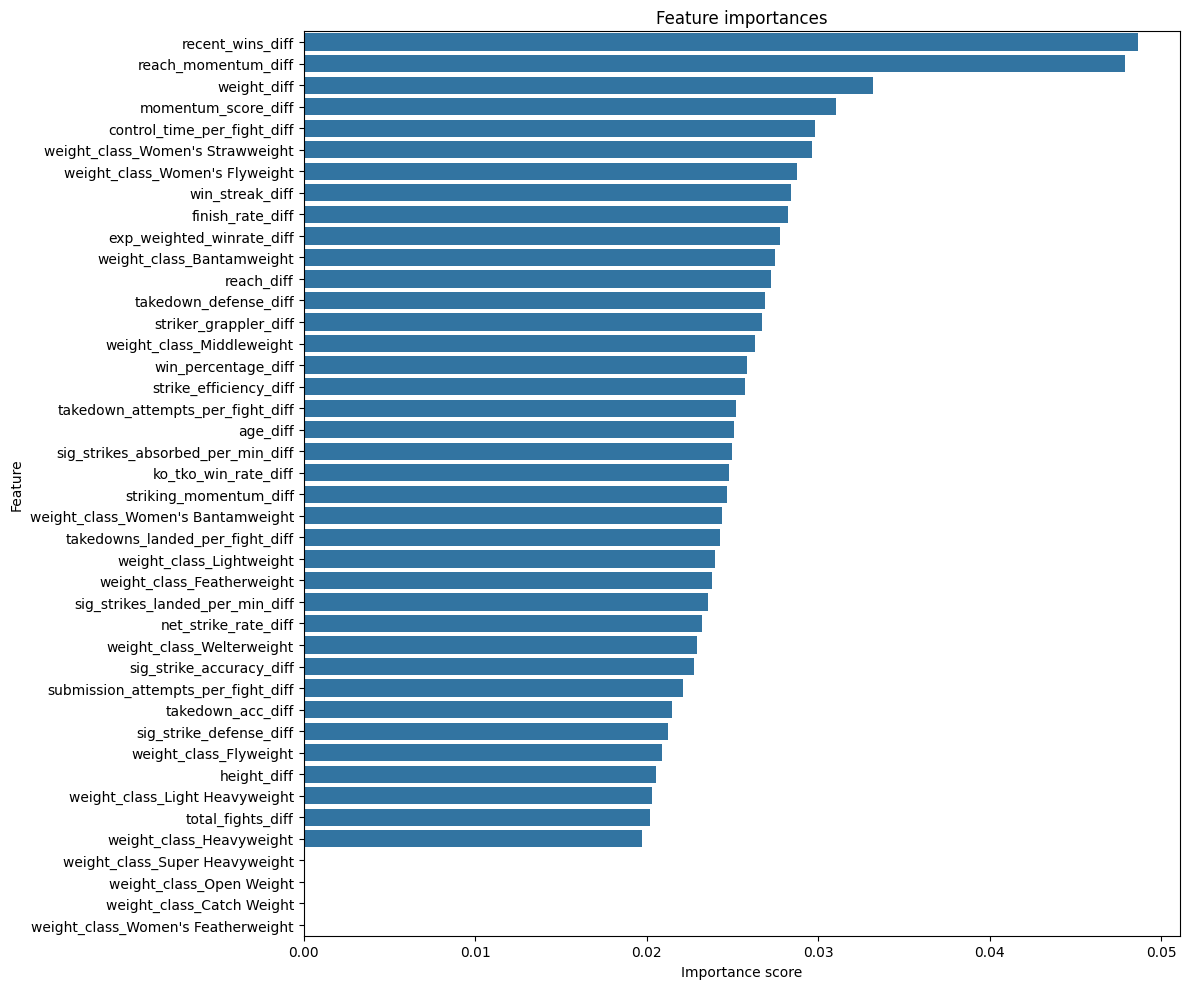

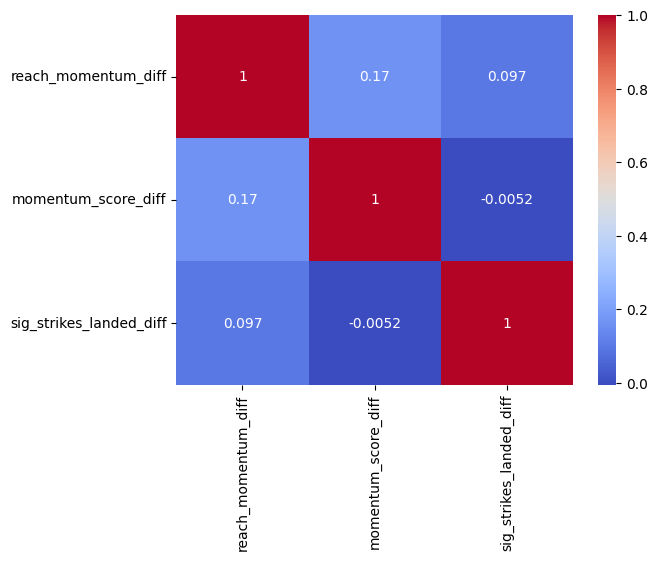

In [ ]:
# 1. Get feature names from the ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out() #Categorical columns 

num_features = all_diff_features  # Use your list of numerical columns

# 2. Combine all final column names after preprocessing
all_feature_names = np.concatenate([cat_features, num_features])

# 3. Get importances
importances = model_pipeline.named_steps['classifier'].feature_importances_


# 4. Map names to values
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)


plt.figure(figsize = (12,10))
sns.barplot(x = 'importance', y='feature', data=feature_importance_df)
plt.title("Feature importances")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
# 5. (Optional) Display top N

corr = df[['reach_momentum_diff', 'momentum_score_diff' , 'sig_strikes_landed_diff']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

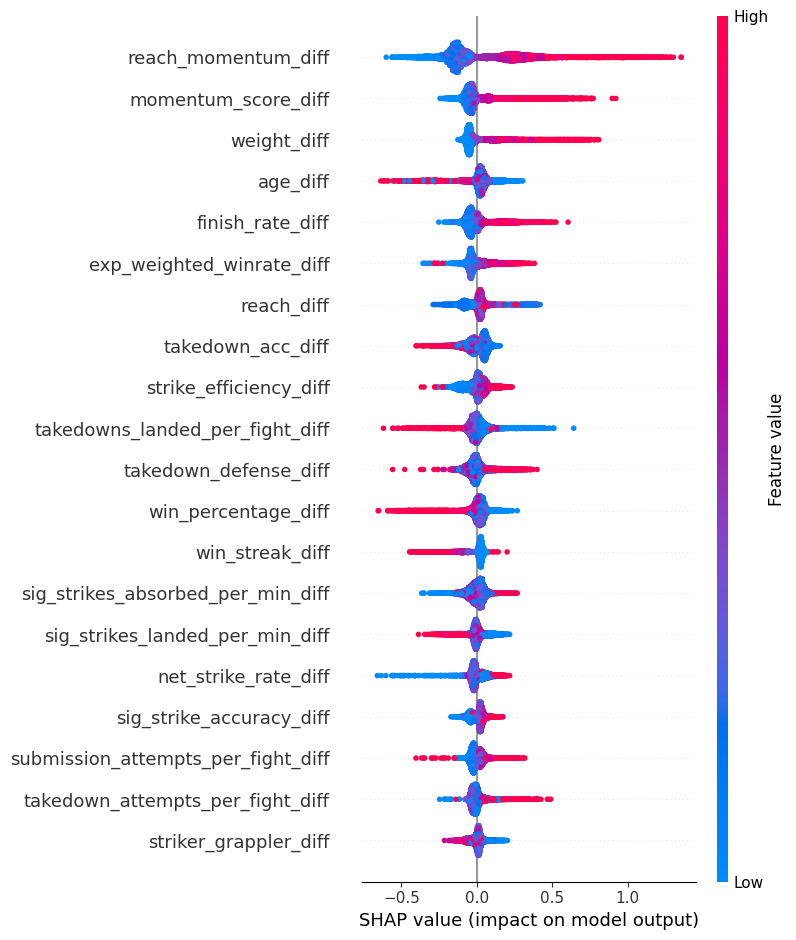

In [ ]:
import shap
explainer = shap.TreeExplainer(model_pipeline.named_steps['classifier'])
X_transformed = model_pipeline.named_steps['preprocessor'].transform(X)
shap_values = explainer.shap_values(X_transformed)
shap.summary_plot(shap_values, features=X_transformed, feature_names = all_feature_names)




In [ ]:
all_known_fighters = pd.concat([df['fighter_a_name'], df['fighter_b_name']])
all_known_fighters



0        Colby Covington
1            Cub Swanson
2             Manel Kape
3          Vitor Petrino
4           Adrian Yanez
              ...       
8052      Chidi Njokuani
8053       Eduarda Moura
8054       Valter Walker
8055          Mike Davis
8056    Melissa Martinez
Length: 16114, dtype: object

In [ ]:
from thefuzz import fuzz 
from thefuzz import process

def find_closest_fighter_name(input_name, all_fighter_names, threshold=80):
    for known_name in all_known_fighters:
        if input_name.lower() == known_name.lower():
            return known_name
    
    best_match, score, index = process.extractOne(input_name, all_known_fighters)
    
    if score >= threshold:
        if score < 100:
            confirmation = input(f"Did you mean {best_match}? Or someone else. (y/n)").lower()
            if confirmation == 'y':
                return best_match
            else:
                print("Correction rejected. Please re-enter the fighter's name")
                return None
        else:
            return best_match
    else:
        print(f"Could not find a Close  match for your fighter in our dataset. Best match found is {best_match}, Please check spelling.")
        return None

 





                          




    

In [ ]:
def get_fighter_stats(fighter_name, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer):
    fighter_data_a = full_df_imputed[full_df_imputed['fighter_a_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    fighter_data_b = full_df_imputed[full_df_imputed['fighter_b_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    
    recent_fight = None
    prefix = '' # Initialize prefix to avoid UnboundLocalError in some paths

    if not fighter_data_a.empty and not fighter_data_b.empty:
        if fighter_data_a.iloc[0]['event_date'] >= fighter_data_b.iloc[0]['event_date']:
            recent_fight = fighter_data_a.iloc[0]
            prefix = 'fighter_a_'
        else:
            recent_fight = fighter_data_b.iloc[0]
            prefix = 'fighter_b_'
    elif not fighter_data_a.empty:
        recent_fight = fighter_data_a.iloc[0]
        prefix = 'fighter_a_'
    elif not fighter_data_b.empty:
        recent_fight = fighter_data_b.iloc[0]
        prefix = 'fighter_b_'
    else:
        return None # Fighter not found

    stats = {}
    for stat in numerical_stats_list:
        full_col_name = prefix + stat
        # Check if the specific stat exists and is not NaN in the fighter's latest record
        if full_col_name in recent_fight.index and pd.notna(recent_fight[full_col_name]):
            stats[stat] = recent_fight[full_col_name]
        else:
            # Fallback: if the stat was truly missing for this fighter (e.g., they only had NaNs for it),
            # use the median value from the overall training data as learned by the imputer.
            try:
                col_index_in_imputer = raw_col_names_for_imputer.index(full_col_name)
                stats[stat] = imputer_fitted_obj.statistics_[col_index_in_imputer]
            except ValueError:
                # Should not happen if `raw_col_names_for_imputer` is correctly formed.
                # If it does, a stat isn't in the imputed list, which is an issue.
                print(f"Warning: Stat '{full_col_name}' not found in imputer's training columns. Defaulting to NaN.")
                stats[stat] = np.nan # Or raise an error
    stats['weight_class'] = recent_fight['weight_class']

    return stats




def get_fighter_stats(fighter_name, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer):
    fighter_data_a = full_df_imputed[full_df_imputed['fighter_a_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    fighter_data_b = full_df_imputed[full_df_imputed['fighter_b_name'] == fighter_name].sort_values(by='event_date', ascending=False)
    
    recent_fight = None
    prefix = '' # Initialize prefix to avoid UnboundLocalError in some paths

    if not fighter_data_a.empty and not fighter_data_b.empty:
        if fighter_data_a.iloc[0]['event_date'] >= fighter_data_b.iloc[0]['event_date']:
            recent_fight = fighter_data_a.iloc[0]
            prefix = 'fighter_a_'
        else:
            recent_fight = fighter_data_b.iloc[0]
            prefix = 'fighter_b_'
    elif not fighter_data_a.empty:
        recent_fight = fighter_data_a.iloc[0]
        prefix = 'fighter_a_'
    elif not fighter_data_b.empty:
        recent_fight = fighter_data_b.iloc[0]
        prefix = 'fighter_b_'
    else:
        return None # Fighter not found

    stats = {}
    for stat in numerical_stats_list:
        full_col_name = prefix + stat
        # Check if the specific stat exists and is not NaN in the fighter's latest record
        if full_col_name in recent_fight.index and pd.notna(recent_fight[full_col_name]):
            stats[stat] = recent_fight[full_col_name]
        else:
            # Fallback: if the stat was truly missing for this fighter (e.g., they only had NaNs for it),
            # use the median value from the overall training data as learned by the imputer.
            try:
                col_index_in_imputer = raw_col_names_for_imputer.index(full_col_name)
                stats[stat] = imputer_fitted_obj.statistics_[col_index_in_imputer]
            except ValueError:
                # Should not happen if `raw_col_names_for_imputer` is correctly formed.
                # If it does, a stat isn't in the imputed list, which is an issue.
                print(f"Warning: Stat '{full_col_name}' not found in imputer's training columns. Defaulting to NaN.")
                stats[stat] = np.nan # Or raise an error
    stats['weight_class'] = recent_fight['weight_class']

    return stats




def predict_fight_winner(fighter1_name, fighter2_name, assumed_weight_class, model, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer, features_for_model):
    
    fighter1_stats = get_fighter_stats(fighter1_name, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer)
    fighter2_stats = get_fighter_stats(fighter2_name, full_df_imputed, imputer_fitted_obj, numerical_stats_list, raw_col_names_for_imputer)
    if fighter1_stats is None:
        return f"Error: Fighter '{fighter1_name}' not found in the dataset."
    if fighter2_stats is None:
        return f"Error: Fighter '{fighter2_name}' not found in the dataset."

    # Calculate all diff features for the prediction instance
    prediction_data = {}
    for stat in numerical_stats_list:
        # Ensure stats are valid numbers before diff calculation
        f1_val = fighter1_stats.get(stat, np.nan)
        f2_val = fighter2_stats.get(stat, np.nan)
        # Handle cases where one or both values might be NaN (should be handled by get_fighter_stats, but defensive)
        if pd.isna(f1_val) or pd.isna(f2_val):
            prediction_data[f'{stat}_diff'] = 0.0 # Or use mean_diff if calculated globally
            print(f"Warning: Missing stat for '{stat}' in {fighter1_name} or {fighter2_name}, defaulting diff to 0.")
        else:
            prediction_data[f'{stat}_diff'] = f1_val - f2_val

    prediction_data['weight_class'] = assumed_weight_class

    # Create a DataFrame for prediction, ensuring columns are in the same order as X_train
    # This is crucial for the ColumnTransformer and the model.
    predict_df = pd.DataFrame([prediction_data])[[col for col in features_for_model if col in prediction_data]] # Select only necessary features and preserve order
    # Add any missing diff features with 0 if they don't get generated (shouldn't happen with full NUMERICAL_FIGHTER_STATS)
    for col in [f for f in features_for_model if f not in predict_df.columns]:
        predict_df[col] = 0.0

    # Make the prediction
    prediction = model.predict(predict_df)[0]
    prediction_proba = model.predict_proba(predict_df)[0]
    # Interpret the prediction
    if prediction == 1:
        winner = fighter1_name
        confidence = prediction_proba[1] # Probability of fighter A winning
    else:
        winner = fighter2_name
        confidence = prediction_proba[0] # Probability of fighter B winning (i.e., fighter A losing)

    return f"Predicted Winner: {winner} (Confidence: {confidence:.2f})"

# --- User Interaction ---
print("\n--- UFC Fight Predictor (Comprehensive) ---")
print("Enter fighter names and the weight class for the hypothetical fight.")
print("Names must match those in the dataset exactly (e.g., 'Dustin Jacoby', 'Adrian Yanez').")
print("Common weight classes: Light Heavyweight, Bantamweight, Lightweight, Featherweight, Women's Flyweight, Women's Strawweight, Flyweight, Welterweight, Heavyweight, Middleweight, Catch Weight.")


test_cases = [
    ("Ilia Topuria", "Arman Tsarukyan", "Lightweight"),
    ("Islam Makhachev", "Dricus Du Plessis", "Welterweight"),
    ("Ilia Topuria", "Islam Makhachev", "Lightweight"),
    ("Khamzat Chimaev", "Dricus Du Plessis", "Middleweight"),
    ("Dricus Du Plessis", "Khamzat Chimaev", "Middleweight"),
    ("Sean Strickland", "Robert whittaker", "Middleweight"),
    ("Max holloway", "Dustin Poirier", "Lightweight"),
    ("Dustin Poirier", "Max holloway", "Lightweight"),
    ("Daniel Rodriguez", "Kevin Holland", "Middleweight"),
    ("Kevin Holland", "Daniel Rodriguez", "Middleweight"),
    ("Islam Makhachev", "Jack Dela Maddalena", "Welterweight")
    
]

for i, (f1, f2, wc) in enumerate(test_cases):
    print(f"\n--- Test Case {i+1} ---")
    print(f"Simulating input: Fighter 1: '{f1}', Fighter 2: '{f2}', Weight Class: '{wc}'")

    fighter1_name_exact = find_closest_fighter_name(f1, all_known_fighters)
    if fighter1_name_exact is None:
        print(f"Skipping prediciton because of unresolved fighter name for fighter name, {f1}")
        continue

    fighter2_name_exact = find_closest_fighter_name(f2, all_known_fighters)
    if fighter2_name_exact is None:
        print(f"Skipping prediciton because of unresolved fighter name for fighter name, {f1}")
        continue

    # Pass all necessary objects to the prediction function
    result = predict_fight_winner(fighter1_name_exact, fighter2_name_exact, wc, model_pipeline, df, imputer, NUMERICAL_FIGHTER_STATS, all_numerical_raw_cols, model_features)
    print(result)

print("\n--- End of Simulated Predictions ---")
print("\nIf you were running this interactively, the prompt would continue now.")




--- UFC Fight Predictor (Comprehensive) ---
Enter fighter names and the weight class for the hypothetical fight.
Names must match those in the dataset exactly (e.g., 'Dustin Jacoby', 'Adrian Yanez').
Common weight classes: Light Heavyweight, Bantamweight, Lightweight, Featherweight, Women's Flyweight, Women's Strawweight, Flyweight, Welterweight, Heavyweight, Middleweight, Catch Weight.

--- Test Case 1 ---
Simulating input: Fighter 1: 'Ilia Topuria', Fighter 2: 'Arman Tsarukyan', Weight Class: 'Lightweight'
Predicted Winner: Ilia Topuria (Confidence: 0.51)

--- Test Case 2 ---
Simulating input: Fighter 1: 'Islam Makhachev', Fighter 2: 'Dricus Du Plessis', Weight Class: 'Welterweight'
Predicted Winner: Dricus Du Plessis (Confidence: 0.51)

--- Test Case 3 ---
Simulating input: Fighter 1: 'Ilia Topuria', Fighter 2: 'Islam Makhachev', Weight Class: 'Lightweight'
Predicted Winner: Islam Makhachev (Confidence: 0.51)

--- Test Case 4 ---
Simulating input: Fighter 1: 'Khamzat Chimaev', Figh

In [ ]:
latest_fights = df.sort_values(by='event_date', ascending=False).head(3)
latest_fights



,fight_id,event_date,weight_class,outcome,fighter_a_name,fighter_b_name,fighter_a_age,fighter_a_height,fighter_a_reach,fighter_a_weight,...,finish_rate_diff,takedown_acc_diff,exp_weighted_winrate_diff,momentum_score_diff,finisher_vs_weak_defense_flag,striking_momentum_diff,fighter_a_norm_momentum,fighter_b_norm_momentum,reach_momentum_diff,hybrid_striker_score
8039,72e477b41f44e358,2025-07-19,Middleweight,1,Ateba Gautier,Robert Valentin,23.3,76.0,81.0,185.0,...,1.106818,0.000000,300.0,6.857143,0,16.80,24.300000,0.000000,243.0,10.389527
8043,74099d470e8d2765,2025-07-19,Middleweight,1,Brunno Ferreira,Jackson McVey,32.7,70.0,72.0,185.0,...,1.357143,3.571426,800.0,24.465116,0,34.29,25.411765,0.000000,432.0,17.736980
8031,d7507e2741fd4d05,2025-07-19,Lightweight,1,Max Holloway,Dustin Poirier,33.6,71.0,69.0,145.0,...,0.955556,0.970356,300.0,5.200000,0,1.96,11.500000,8.780488,54.0,1.483714


In [ ]:
import re
from thefuzz import fuzz 
from thefuzz import process
import requests
from bs4 import BeautifulSoup
import streamlit as st
def find_closest_fighter_name(input_name):
    result = process.extractOne(input_name, all_known_fighters)
    return result[0] if result else None


def get_fighter_photo(exact_name):
    name_list  = re.sub(r'[^a-z0-9\s-]', '', exact_name.lower()).split()
    final_name = '-'.join(name_list)

    fighter_url = f"https://ufc.com/athlete/{final_name}"
    headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36'
    }

    try:
        response = requests.get(fighter_url, timeout= 10, headers=headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        img_tag = soup.find('img', alt=exact_name)

        if img_tag and 'src' in img_tag.attrs:
            img_url = img_tag['src'] 
            return img_url  
        else:
            st.warning(f"Could not find profile image for {exact_name}")
            return ""

    except Exception as e:
        st.error(f"Failed to fetch ufc.com page for {exact_name}")
        return ""


name1 = find_closest_fighter_name("Dricus Du Plessis")
print(name1)
print(get_fighter_photo(name1))

Dricus Du Plessis
https://ufc.com/images/styles/athlete_bio_full_body/s3/2025-02/DU_PLESSIS_DRICUS_L_BELT_02-08.png?itok=bUksExyJ
